<a href="https://colab.research.google.com/github/jtech-sudo/Gad/blob/main/ProjetProfessionnellePredictionDiabete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import de base et options d'affichage
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="notebook")  # joli thème pour seaborn

# sklearn et utilitaires ML
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # pour IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve, auc)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils import resample
import joblib

# Optional libs
try:
    from imblearn.over_sampling import SMOTE
    has_smote = True
except:
    has_smote = False

try:
    import shap
    has_shap = True
except:
    has_shap = False

# Affichage inline des graphiques (pour Jupyter/Colab)
%matplotlib inline

print("Pandas:", pd.__version__, "NumPy:", np.__version__)
print("SMOTE disponible:", has_smote, "SHAP disponible:", has_shap)

Pandas: 2.2.2 NumPy: 2.0.2
SMOTE disponible: True SHAP disponible: True


In [ ]:
from google.colab  import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
df = pd.read_csv('diabetes.csv')

print("Taille du dataset:", df.shape)
display(df.head(8))
display(df.info())  # types et non-null

Taille du dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


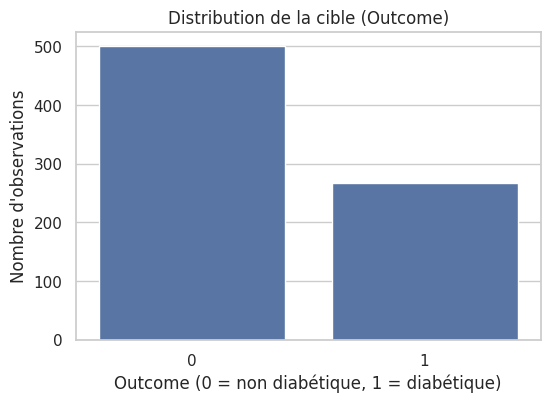

Proportion (Outcome=1): 34.90%


In [ ]:
# Statistiques de base
display(df.describe().T)

# Distribution de la variable cible Outcome
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title("Distribution de la cible (Outcome)")
plt.xlabel("Outcome (0 = non diabétique, 1 = diabétique)")
plt.ylabel("Nombre d'observations")
plt.show()

print("Proportion (Outcome=1): {:.2%}".format(df['Outcome'].mean()))


Glucose: 5 zéros (potentiellement manquants)
BloodPressure: 35 zéros (potentiellement manquants)
SkinThickness: 227 zéros (potentiellement manquants)
Insulin: 374 zéros (potentiellement manquants)
BMI: 11 zéros (potentiellement manquants)


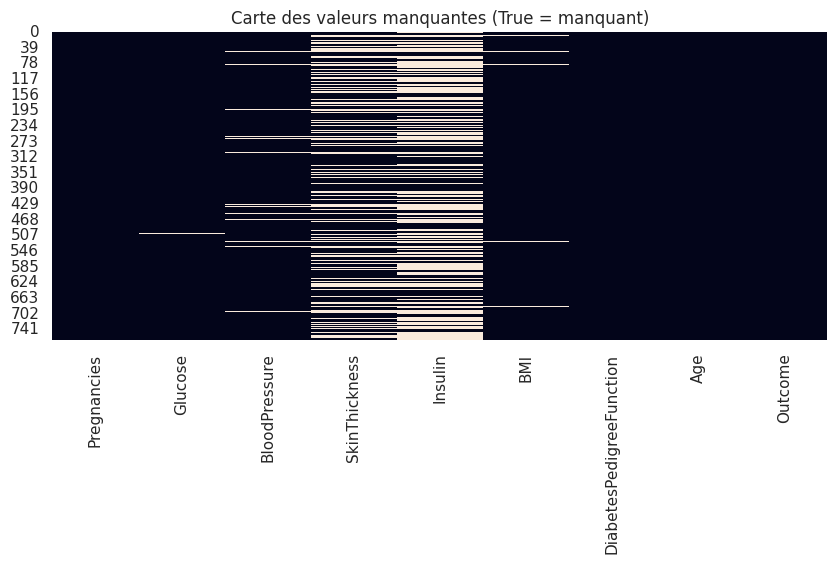

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# Colonnes où 0 est physiologiquement impossible -> souvent missing déguisé
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for c in zero_cols:
    print(f"{c}: { (df[c] == 0).sum() } zéros (potentiellement manquants)")

# Remplacer 0 par NaN pour ces colonnes pour l'analyse initiale (mais on gardera df original si besoin)
df_missing = df.copy()
df_missing[zero_cols] = df_missing[zero_cols].replace(0, np.nan)

# Heatmap des valeurs manquantes
plt.figure(figsize=(10,4))
sns.heatmap(df_missing.isna(), cbar=False)
plt.title("Carte des valeurs manquantes (True = manquant)")
plt.show()

display(df_missing.isna().sum())


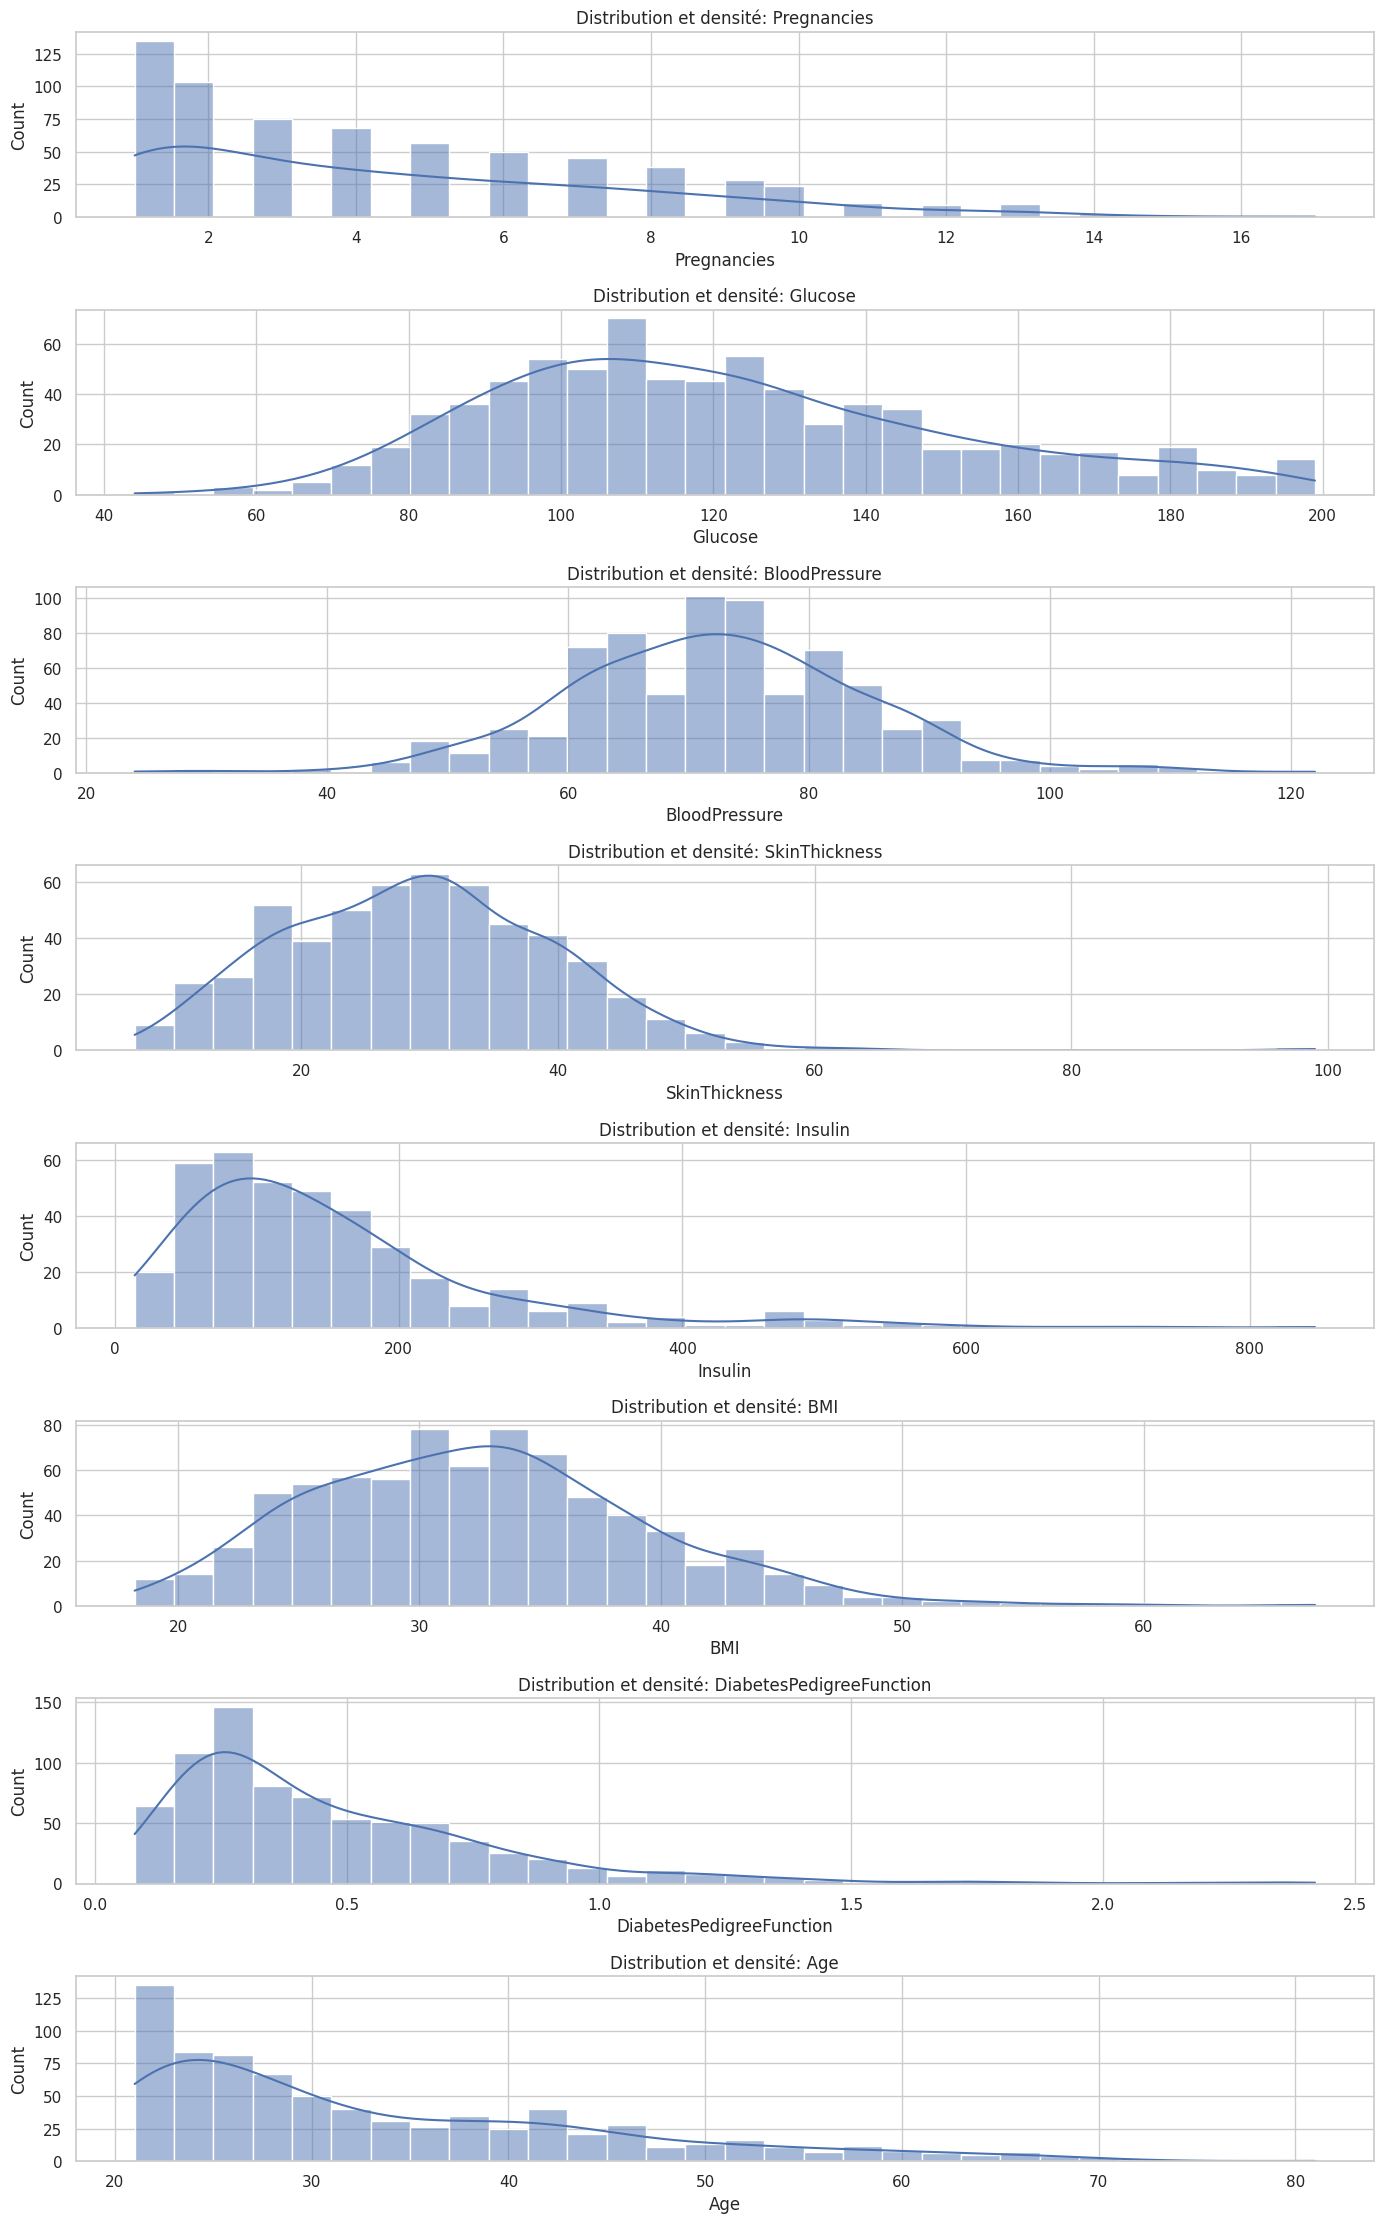

In [ ]:
# Histogrammes + KDE (densité) pour chaque variable numérique
num_cols = df.columns.drop('Outcome')
n = len(num_cols)
plt.figure(figsize=(14, 2.8 * n))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n, 1, i)
    sns.histplot(df[col].replace(0, np.nan), kde=True, bins=30)  # remplace 0 par NaN pour l'aspect visuel
    plt.title(f"Distribution et densité: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

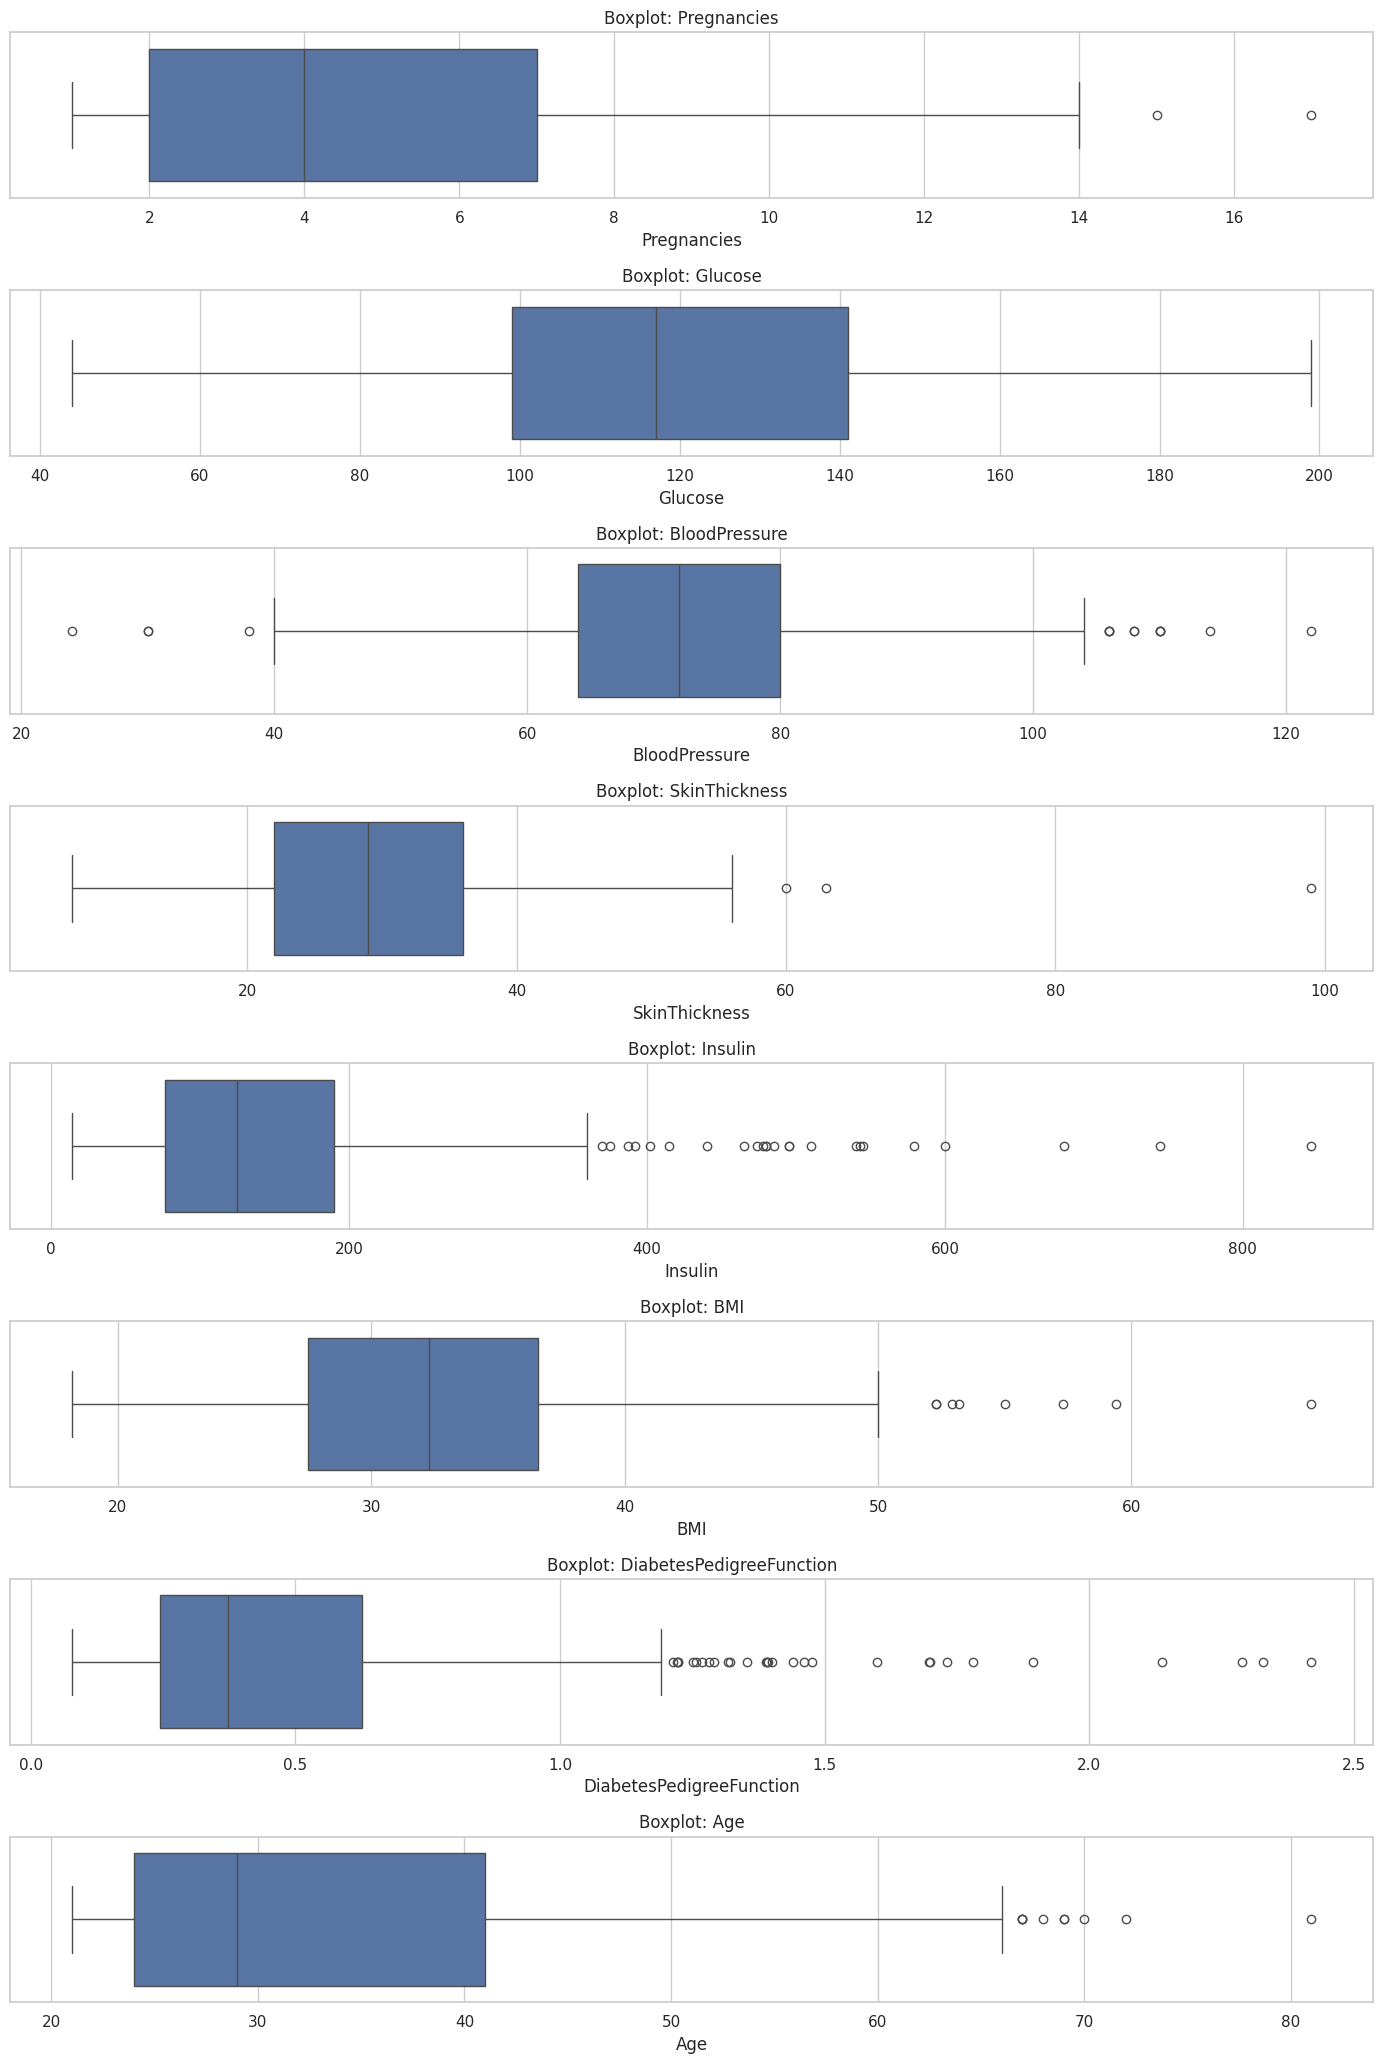

In [ ]:
plt.figure(figsize=(14, 2.6 * len(num_cols)))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=df[col].replace(0, np.nan))
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()


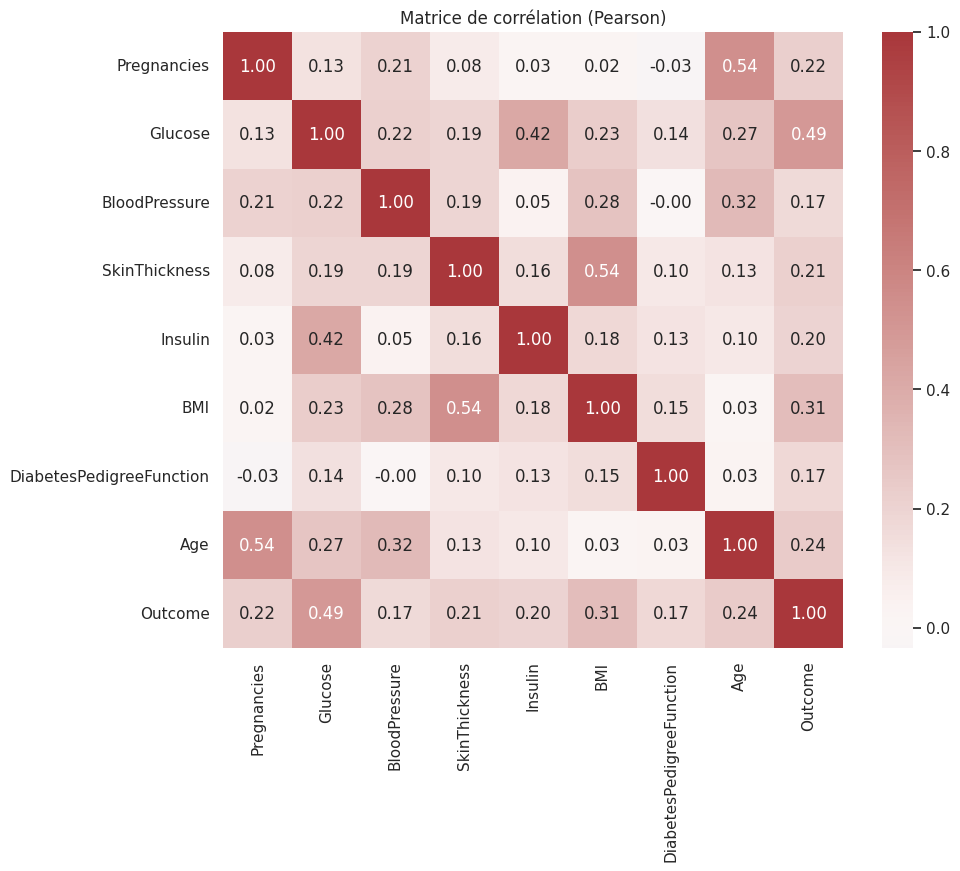

In [ ]:
# Corrélation (remplacer 0 par NaN puis imputer temporairement par la médiane pour la corrélation)
tmp = df.copy()
tmp[zero_cols] = tmp[zero_cols].replace(0, np.nan)
tmp[zero_cols] = tmp[zero_cols].fillna(tmp[zero_cols].median())

corr = tmp.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Matrice de corrélation (Pearson)")
plt.show()


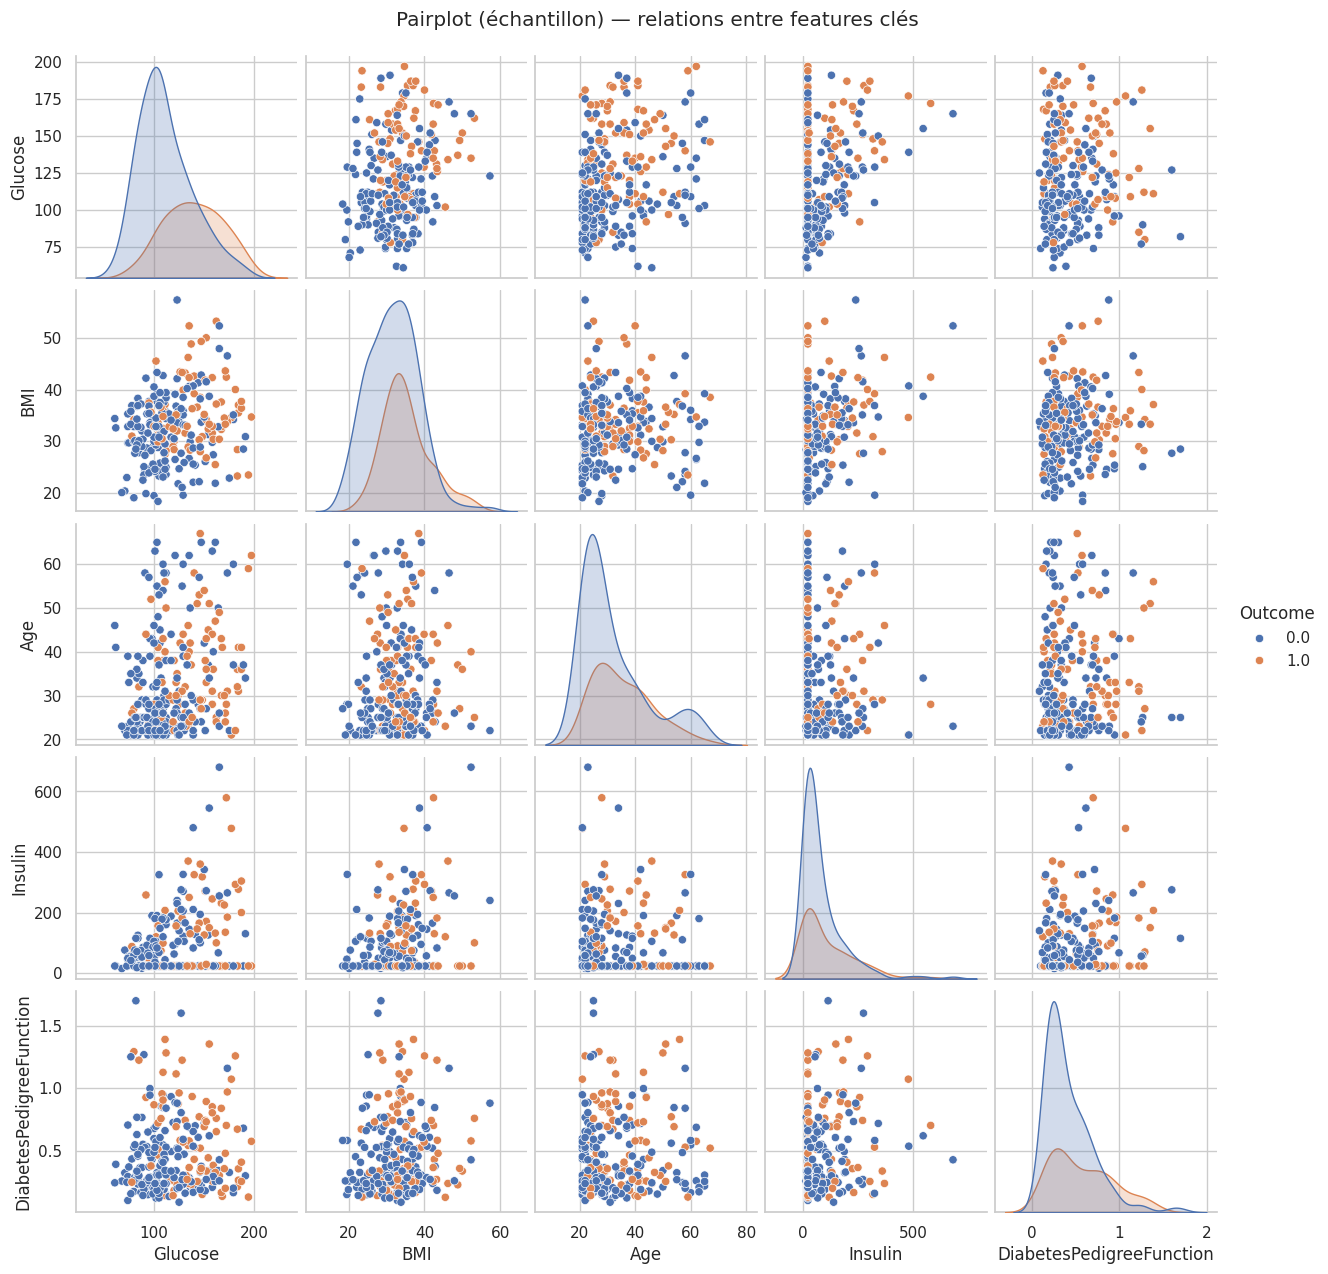

In [ ]:
# Warning: pairplot peut être lent; réduire si besoin (échantillon)
sample = df.sample(n=250, random_state=42) if df.shape[0] > 250 else df
sns.pairplot(sample.replace(0, np.nan).fillna(sample.median()), hue="Outcome", diag_kind="kde",
             vars=['Glucose','BMI','Age','Insulin','DiabetesPedigreeFunction'])
plt.suptitle("Pairplot (échantillon) — relations entre features clés", y=1.02)
plt.show()


In [ ]:
from scipy.stats import shapiro, mannwhitneyu

# Test de normalité (Shapiro) pour quelques features
for col in ['Glucose','BMI','Age']:
    s = df[col].replace(0, np.nan).dropna()
    if len(s) > 3:
        stat, p = shapiro(s.sample(500) if len(s) > 500 else s)  # échantillon si grand
        print(f"Shapiro {col}: stat={stat:.3f}, p={p:.3f} -> {'non normal' if p<0.05 else 'normal'}")

# Test de différence de distributions (Outcome=0 vs Outcome=1) pour Glucose
g0 = df[df['Outcome']==0]['Glucose'].replace(0, np.nan).dropna()
g1 = df[df['Outcome']==1]['Glucose'].replace(0, np.nan).dropna()
stat, p = mannwhitneyu(g0, g1)  # test non-paramétrique
print(f"\nMann-Whitney Glucose: stat={stat:.3f}, p={p:.6f} (p<0.05 => distributions différentes)")

Shapiro Glucose: stat=0.967, p=0.000 -> non normal
Shapiro BMI: stat=0.983, p=0.000 -> non normal
Shapiro Age: stat=0.866, p=0.000 -> non normal

Mann-Whitney Glucose: stat=27393.500, p=0.000000 (p<0.05 => distributions différentes)


In [ ]:
# On travaille à partir d'une copie
df_prep = df.copy()

# Remplacer 0 par NaN (colonne ciblées)
df_prep[zero_cols] = df_prep[zero_cols].replace(0, np.nan)

# Feature engineering simple: ratio Age / Pregnancies, BMI * Glucose (exemple hypothétique)
df_prep['Age_per_preg'] = df_prep['Age'] / (df_prep['Pregnancies'] + 1)
df_prep['BMI_Glucose'] = df_prep['BMI'] * df_prep['Glucose']

display(df_prep.head())

# Comparer imputation: médiane, KNN, Iterative
X_raw = df_prep.drop(columns=['Outcome'])
y_raw = df_prep['Outcome']

# 1) Imputation médiane
imp_median = SimpleImputer(strategy='median')
X_med = pd.DataFrame(imp_median.fit_transform(X_raw), columns=X_raw.columns)

# 2) KNN Imputer
imp_knn = KNNImputer(n_neighbors=5)
X_knn = pd.DataFrame(imp_knn.fit_transform(X_raw), columns=X_raw.columns)

# 3) Iterative Imputer (Regressor-based)
imp_iter = IterativeImputer(random_state=42, max_iter=10)
X_iter = pd.DataFrame(imp_iter.fit_transform(X_raw), columns=X_raw.columns)

print("Shapes:", X_med.shape, X_knn.shape, X_iter.shape)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_per_preg,BMI_Glucose
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,7.142857,4972.8
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,15.500000,2261.0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,3.555556,4263.9
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,10.500000,2500.9
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,33.000000,5904.7


Shapes: (768, 10) (768, 10) (768, 10)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
from sklearn.model_selection import cross_validate
clf = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)

def cv_score(Xi, y, clf, cv=5):
    scores = cross_validate(clf, Xi, y, scoring='roc_auc', cv=cv, n_jobs=-1, return_train_score=False)
    return scores['test_score'].mean(), scores['test_score'].std()

print("CV AUC (median):", cv_score(X_med, y_raw, clf))
print("CV AUC (knn):   ", cv_score(X_knn, y_raw, clf))
print("CV AUC (iter):  ", cv_score(X_iter, y_raw, clf))


CV AUC (median): (np.float64(0.8285359888190076), np.float64(0.036847822778554064))
CV AUC (knn):    (np.float64(0.8249388539482879), np.float64(0.03626292750011047))
CV AUC (iter):   (np.float64(0.8228832983927324), np.float64(0.030387287260857297))


In [ ]:
# Supposons que IterativeImputer a été retenu (ou change X_selected selon ton test)
X_final = X_iter.copy()  # remplace par X_med ou X_knn si tu préfères
y_final = y_raw.values

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)
print("Train/Test shapes:", X_train.shape, X_test.shape)

# Standardisation (fit sur train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train/Test shapes: (614, 10) (154, 10)


In [ ]:
if has_smote:
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
    print("SMOTE applied. New train shape:", X_res.shape)
else:
    # Oversampling simple
    df_tr = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    df_tr['Outcome'] = y_train
    df_major = df_tr[df_tr['Outcome']==0]
    df_min = df_tr[df_tr['Outcome']==1]
    df_min_up = resample(df_min, replace=True, n_samples=len(df_major), random_state=42)
    df_res = pd.concat([df_major, df_min_up])
    X_res = df_res.drop(columns=['Outcome']).values
    y_res = df_res['Outcome'].values
    print("Random oversample applied. New train shape:", X_res.shape)


SMOTE applied. New train shape: (800, 10)


In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

# Setup des modèles à tester
models = {
    'LogReg': LogisticRegression(max_iter=200, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

# Espaces d'hyperparamètres (compact pour rapidité)
param_distributions = {
    'LogReg': {'C': [0.01,0.1,1,10,100]},
    'RandomForest': {'n_estimators':[100,200,400], 'max_depth':[None,5,10,20]},
    'XGBoost': {'n_estimators':[100,200], 'max_depth':[3,5,8], 'learning_rate':[0.01,0.1,0.2]}
}

best_estimators = {}
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

for name in models:
    print(f"\nTuning {name} ...")
    rsearch = RandomizedSearchCV(models[name], param_distributions[name], n_iter=6,
                                 scoring='roc_auc', cv=cv, n_jobs=-1, random_state=42, verbose=1)
    rsearch.fit(X_res, y_res)
    print("Best params:", rsearch.best_params_, "Best AUC:", rsearch.best_score_)
    best_estimators[name] = rsearch.best_estimator_



Tuning LogReg ...
Fitting 4 folds for each of 5 candidates, totalling 20 fits
Best params: {'C': 0.1} Best AUC: 0.8477999999999999

Tuning RandomForest ...
Fitting 4 folds for each of 6 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=6. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'n_estimators': 400, 'max_depth': None} Best AUC: 0.8879125

Tuning XGBoost ...
Fitting 4 folds for each of 6 candidates, totalling 24 fits
Best params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1} Best AUC: 0.8687


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:39:27] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Compare les modèles sur le test set
eval_results = {}
for name, model in best_estimators.items():
    # si besoin, re-fit sur X_res complet (déjà fit par RandomizedSearch) - utiliser directement
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    eval_results[name] = {'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'roc_auc':roc}
    print(f"\n{name} results:")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC AUC:", roc)
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))



LogReg results:
Accuracy: 0.7207792207792207
Precision: 0.5873015873015873
Recall: 0.6851851851851852
F1: 0.6324786324786325
ROC AUC: 0.8053703703703704
Confusion matrix:
 [[74 26]
 [17 37]]
Classification report:
               precision    recall  f1-score   support

           0       0.81      0.74      0.77       100
           1       0.59      0.69      0.63        54

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154


RandomForest results:
Accuracy: 0.7207792207792207
Precision: 0.5873015873015873
Recall: 0.6851851851851852
F1: 0.6324786324786325
ROC AUC: 0.8187037037037037
Confusion matrix:
 [[74 26]
 [17 37]]
Classification report:
               precision    recall  f1-score   support

           0       0.81      0.74      0.77       100
           1       0.59      0.69      0.63        54

    accuracy                           0.72       154
   macro avg     

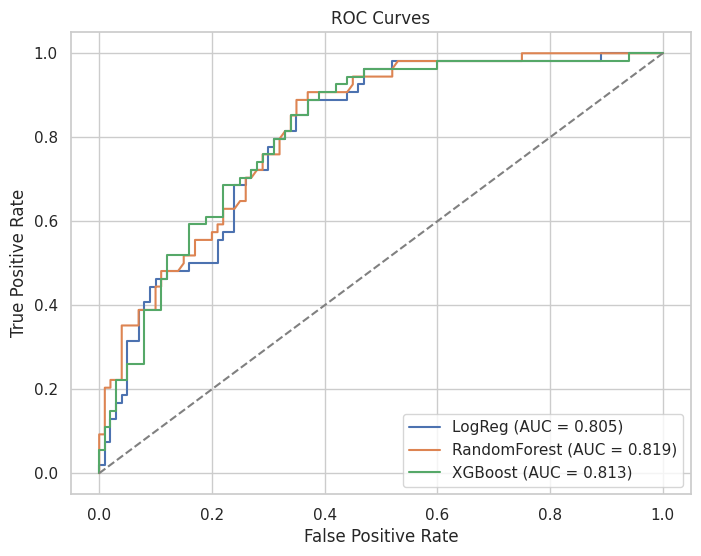

In [ ]:
plt.figure(figsize=(8,6))
for name, model in best_estimators.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1], linestyle='--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.show()


Meilleur modèle choisi pour SHAP: RandomForest


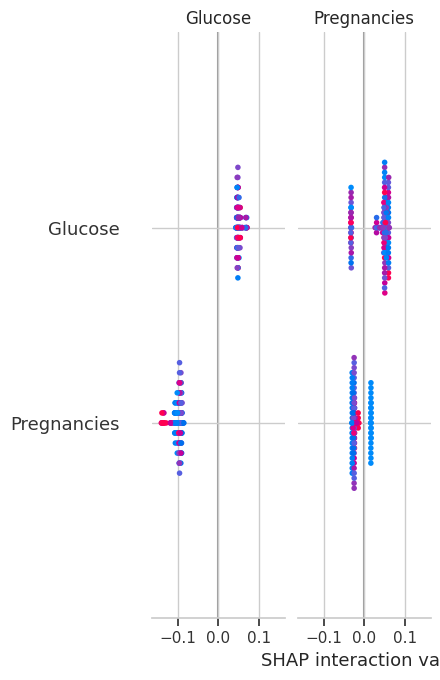

In [ ]:
# Identifie le meilleur modèle selon AUC calculée plus haut (ex: XGBoost ou RandomForest)
# Remplace 'XGBoost' par le nom qui a le meilleur roc_auc dans eval_results
best_name = max(eval_results.items(), key=lambda x: (x[1]['roc_auc'] if x[1]['roc_auc'] is not None else -1))[0]
best_model = best_estimators[best_name]
print("Meilleur modèle choisi pour SHAP:", best_name)

if has_shap and hasattr(best_model, "predict_proba"):
    # Utiliser TreeExplainer si modèle d'arbre
    if hasattr(shap, "TreeExplainer"):
        explainer = shap.TreeExplainer(best_model)
        # Utiliser X_test_scaled inverse transform? Construire DataFrame avec noms de colonnes
        X_test_df = pd.DataFrame(scaler.inverse_transform(X_test_scaled), columns=X_final.columns)
        shap_values = explainer.shap_values(X_test_df)
        # summary plot
        shap.summary_plot(shap_values, X_test_df)
    else:
        print("SHAP installé mais TreeExplainer non disponible.")
else:
    print("SHAP non installé ou modèle non compatible. Pour l'installer: pip install shap")


In [ ]:
# Sauvegarde du meilleur modèle et du scaler
joblib.dump(best_model, "/content/diabetes_best_model.joblib")
joblib.dump(scaler, "/content/diabetes_scaler.joblib")
print("Modèle et scaler sauvés dans /content/")

Modèle et scaler sauvés dans /content/


In [ ]:
# Exemple : wrapper predict (utilise scaler et meilleur modèle sauvegardés)
def predict_patient(input_dict, model=best_model, scaler=scaler):
    """
    input_dict: dict with keys matching X_final.columns
    returns: dict with probability and class prediction
    """
    df_in = pd.DataFrame([input_dict])
    # Imputer manquant si besoin (ici on suppose que tu as utilisé IterativeImputer précédemment)
    # Pour la démonstration on remplit par la médiane
    df_in = df_in.fillna(df_final_median := pd.DataFrame(X_final, columns=X_final.columns).median())
    # Scale
    Xs = scaler.transform(df_in)
    proba = model.predict_proba(Xs)[:,1][0]
    pred = int(proba >= 0.5)
    return {"probability": proba, "prediction": pred}

# Exemple d'utilisation
example_input = dict(zip(X_final.columns, X_final.iloc[0].tolist()))
print("Exemple d'entrée (première ligne du jeu):")
print(example_input)
print("Prédiction:", predict_patient(example_input))


Exemple d'entrée (première ligne du jeu):
{'Pregnancies': 6.0, 'Glucose': 148.0, 'BloodPressure': 72.0, 'SkinThickness': 35.0, 'Insulin': 214.50643757633117, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.627, 'Age': 50.0, 'Age_per_preg': 7.142857142857143, 'BMI_Glucose': 4972.8}
Prédiction: {'probability': np.float64(0.91), 'prediction': 1}
